In [3]:
import google.auth                                                                                                           
try:                                                                                                                         
        credentials, project_id = google.auth.default()                                                                          
        print("Credentials type: {type(credentials)}")                                                                        
        print("Project ID: {project_id}")                                                                                     
        if credentials.service_account_email:                                                                                    
            print("Service Account Email: {credentials.service_account_email}")                                               
        else:                                                                                                                    
            print("Not using a service account for authentication.")                                                           
except Exception as e:                                                                                                       
        print("Could not retrieve default credentials: {e}") 

Credentials type: {type(credentials)}
Project ID: {project_id}
Service Account Email: {credentials.service_account_email}


In [2]:
import pandas as pd
from google.cloud import bigquery
import google.auth

# --- Configuration ---
PROJECT_ID = 'microgrid-demo'
DATASET_ID = 'microgrid_db'
TABLE_ID = 'microgrid_telemetry'
LOCATION = 'australia-southeast1' # BigQuery dataset location (region)

# Initialize BigQuery client
credentials, default_project_id = google.auth.default()
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

# --- Fetch Data from BigQuery ---
# This query fetches the latest 1000 records from the telemetry table
# You might adjust this based on your data volume and processing needs.
query = f"""
SELECT
    timestamp,
    site_id,
    battery_v,
    battery_soc,
    battery_current,
    battery_temp,
    ac_input_v,
    ac_output_v,
    ac_output_i,
    ac_input_power,
    ac_output_power,
    solar_w,
    load_w,
    inverter_state,
    inverter_temp,
    fault_code,
    power_balance_w
FROM
    `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
ORDER BY
    timestamp DESC
LIMIT 1000
"""

# Run the query and load results into a Pandas DataFrame
try:
    df = client.query(query).to_dataframe()
    print(f"Successfully fetched {len(df)} records from BigQuery.")
    print("DataFrame head:")
    print(df.head())
    print("DataFrame info:")
    df.info()

except Exception as e:
    print(f"An error occurred: {e}")

# --- Basic Feature Engineering (Example) ---
# Convert timestamp to datetime objects and set as index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Sort by timestamp (important for time-series operations)
df = df.sort_index()

# Example: Calculate a rolling mean for battery_soc for each site
# This is a common technique for anomaly detection (deviation from rolling average)
# For more advanced feature engineering, consider group-by operations on 'site_id'

# Ensure data is sorted by site_id and then timestamp for correct rolling calculations
df_sorted = df.sort_values(by=['site_id', 'timestamp'])

# Calculate rolling mean of battery_soc for each site
df_sorted['battery_soc_rolling_mean_5min'] = df_sorted.groupby('site_id')['battery_soc'].transform(lambda x: x.rolling('5min').mean())
df_sorted['battery_soc_deviation_5min'] = df_sorted['battery_soc'] - df_sorted['battery_soc_rolling_mean_5min']

print("DataFrame with new features head:")
print(df_sorted.head())

# Further steps would involve more complex feature engineering,
# model selection, training, evaluation, and deployment using Vertex AI services.

Successfully fetched 1000 records from BigQuery.
DataFrame head:
                         timestamp  site_id  battery_v  battery_soc  \
0 2026-03-27 09:26:23.826965+00:00  site-10      25.22         35.1   
1 2026-03-27 09:26:23.825608+00:00  site-09      25.23         35.3   
2 2026-03-27 09:26:23.824445+00:00  site-06      25.21         35.5   
3 2026-03-27 09:26:23.823308+00:00  site-05      25.25         35.6   
4 2026-03-27 09:26:23.822014+00:00  site-02      25.26         35.2   

   battery_current  battery_temp  ac_input_v  ac_output_v  ac_output_i  \
0           -60.10          34.0       230.9        230.2         3.44   
1           -69.86          36.0       230.8        231.4         2.66   
2           -42.27          30.5       231.8        230.1         5.34   
3           -52.84          32.6       231.7        230.1         4.44   
4           -65.26          35.1       231.1        230.1         3.20   

   ac_input_power  ac_output_power  solar_w  load_w  inverter_s

In [4]:
# ── CELL 2 ──────────────────────────────────────────────────────────────────
query_full = """
SELECT
site_id, timestamp,
battery_v, battery_soc, battery_current, battery_temp,
ac_input_v, ac_output_v, ac_output_i,
ac_input_power, ac_output_power,
solar_w, load_w, inverter_state, inverter_temp,
fault_code, power_balance_w
FROM `microgrid-demo.microgrid_db.microgrid_telemetry`
ORDER BY site_id, timestamp ASC
"""
df_train = client.query(query_full).to_dataframe()
print(f"Fetched {len(df_train):,} rows | {df_train['site_id'].nunique()} sites")
print(f"Date range: {df_train['timestamp'].min()} -> {df_train['timestamp'].max()}")

Fetched 49,344 rows | 12 sites
Date range: 2026-03-26 00:25:41+00:00 -> 2026-03-27 09:42:44.743151+00:00


In [5]:
# ── CELL 3 ──────────────────────────────────────────────────────────────────
import numpy as np

df_train['timestamp'] = pd.to_datetime(df_train['timestamp'])
df_train = df_train.sort_values(['site_id', 'timestamp']).reset_index(drop=True)

df_train['battery_v_norm'] = df_train['battery_v'] / 24.0

df_train['efficiency_ratio'] = (
    df_train['ac_output_power'] /
    (df_train['ac_input_power'] + df_train['solar_w']).replace(0, np.nan)
)

df_train['prev_soc'] = df_train.groupby('site_id')['battery_soc'].shift(1)
df_train['prev_ts'] = df_train.groupby('site_id')['timestamp'].shift(1)
dt_seconds = (df_train['timestamp'] - df_train['prev_ts']).dt.total_seconds()
df_train['soc_rate_per_min'] = (
    (df_train['battery_soc'] - df_train['prev_soc']) / dt_seconds * 60
)

df_train['hour_bucket'] = df_train['timestamp'].dt.floor('h')
transitions = (
    df_train.groupby(['site_id', 'hour_bucket'])['inverter_state']
    .transform(lambda x: (x != x.shift()).sum())
)
df_train['mode_transitions_per_hour'] = transitions

df_feat = df_train.dropna(subset=['soc_rate_per_min', 'efficiency_ratio']).copy()
print(f"Training rows after feature engineering: {len(df_feat):,}")
print(df_feat[['battery_v_norm','efficiency_ratio','soc_rate_per_min','mode_transitions_per_hour']].describe())

Training rows after feature engineering: 23,176
       battery_v_norm  efficiency_ratio  soc_rate_per_min  \
count    23176.000000      23176.000000      23176.000000   
mean         1.039507          2.937532          0.137532   
std          0.032435         71.080078          0.226774   
min          1.005417          0.164426         -0.602911   
25%          1.008750          0.426152          0.000000   
50%          1.033333          0.631393          0.000000   
75%          1.060000          1.165859          0.100000   
max          1.114167       5644.000000          1.199880   

       mode_transitions_per_hour  
count               23176.000000  
mean                    0.170866  
std                     0.376400  
min                     0.000000  
25%                     0.000000  
50%                     0.000000  
75%                     0.000000  
max                     1.000000  


In [6]:
# ── CELL 4 ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'battery_v', 'battery_soc', 'battery_current', 'battery_temp',
    'ac_input_v', 'ac_output_v', 'ac_input_power', 'ac_output_power',
    'solar_w', 'load_w', 'inverter_temp', 'power_balance_w',
    'battery_v_norm', 'efficiency_ratio', 'soc_rate_per_min',
    'mode_transitions_per_hour'
]

X = df_feat[FEATURE_COLS].copy()
X['efficiency_ratio'] = X['efficiency_ratio'].clip(-5, 5)
X['soc_rate_per_min'] = X['soc_rate_per_min'].clip(-10, 10)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (23176, 16)


In [7]:
# ── CELL 5 ──────────────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
model.fit(X_scaled)
print("Model trained.")

df_feat['anomaly_label'] = model.predict(X_scaled)
df_feat['anomaly_score'] = model.score_samples(X_scaled)

n_anomalies = (df_feat['anomaly_label'] == -1).sum()
print(f"Flagged anomalies: {n_anomalies:,} / {len(df_feat):,} ({n_anomalies/len(df_feat)*100:.1f}%)")

Model trained.
Flagged anomalies: 1,159 / 23,176 (5.0%)


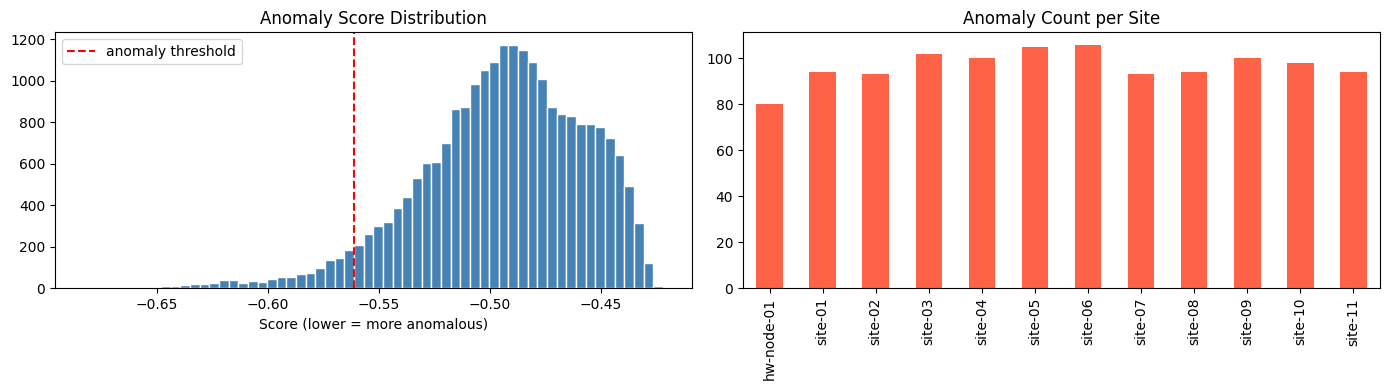


Top 10 most anomalous readings:
   site_id                 timestamp  battery_soc  solar_w  load_w  power_balance_w  anomaly_score
   site-07 2026-03-26 17:54:41+00:00         77.9     90.0  1493.5          -1403.6      -0.682912
   site-03 2026-03-26 17:58:41+00:00         78.2      9.0  1464.0          -1455.0      -0.678049
   site-05 2026-03-26 17:36:41+00:00         76.8    216.3  1495.3          -1279.0      -0.672423
hw-node-01 2026-03-26 17:56:41+00:00         78.0     98.4  1489.0          -1390.6      -0.669724
   site-04 2026-03-26 17:56:41+00:00         78.0     84.5  1488.5          -1403.9      -0.669152
   site-11 2026-03-26 17:47:41+00:00         77.5    177.2  1494.7          -1317.5      -0.668619
   site-11 2026-03-26 17:51:41+00:00         77.7     75.3  1425.8          -1350.5      -0.667727
   site-09 2026-03-26 17:47:41+00:00         77.5    203.4  1482.3          -1278.9      -0.665623
   site-05 2026-03-26 17:38:41+00:00         76.9    325.1  1489.4          

In [8]:
# ── CELL 6 ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_feat['anomaly_score'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(
    df_feat[df_feat['anomaly_label'] == -1]['anomaly_score'].max(),
    color='red', linestyle='--', label='anomaly threshold'
)
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Score (lower = more anomalous)')
axes[0].legend()

anomaly_counts = df_feat[df_feat['anomaly_label'] == -1].groupby('site_id').size()
anomaly_counts.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Anomaly Count per Site')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

cols_show = ['site_id', 'timestamp', 'battery_soc', 'solar_w', 'load_w', 'power_balance_w', 'anomaly_score']
print("\nTop 10 most anomalous readings:")
print(df_feat.nsmallest(10, 'anomaly_score')[cols_show].to_string(index=False))

In [11]:
# ── CELL 7 ──────────────────────────────────────────────────────────────────
import joblib, os, json
from google.cloud import storage
from datetime import date

MODEL_DATE = date.today().isoformat()
BUCKET_NAME = 'microgrid-ml-artefacts'
LOCAL_DIR = f'/tmp/model/{MODEL_DATE}'

os.makedirs(LOCAL_DIR, exist_ok=True)
joblib.dump(model, f'{LOCAL_DIR}/isolation_forest.joblib')
joblib.dump(scaler, f'{LOCAL_DIR}/scaler.joblib')

metadata = {
    'trained_on': MODEL_DATE,
    'n_training_rows': len(df_feat),
    'n_features': len(FEATURE_COLS),
    'feature_cols': FEATURE_COLS,
    'contamination': 0.05,
    'n_estimators': 200,
    'n_anomalies_flagged': int(n_anomalies),
    'sites': sorted(df_feat['site_id'].unique().tolist())
}
with open(f'{LOCAL_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

storage_client = storage.Client(project='microgrid-demo')
bucket = storage_client.bucket(BUCKET_NAME)

files = ['isolation_forest.joblib', 'scaler.joblib', 'metadata.json']
for fname in files:
    bucket.blob(f'models/{MODEL_DATE}/{fname}').upload_from_filename(f'{LOCAL_DIR}/{fname}')
    print(f"Uploaded gs://{BUCKET_NAME}/models/{MODEL_DATE}/{fname}")

Uploaded gs://microgrid-ml-artefacts/models/2026-03-27/isolation_forest.joblib
Uploaded gs://microgrid-ml-artefacts/models/2026-03-27/scaler.joblib
Uploaded gs://microgrid-ml-artefacts/models/2026-03-27/metadata.json
